# Exp 6: Fusion Method Selection — Concat vs Mean vs Gated

**Goal:** Fix best image + text backbones (from Exp 5) and compare fusion strategies.

**Concat result is free** — reused from Exp 5, no retraining.

**Mean and Gated** are tuned inline with Optuna, then retrained with best params.

**Fusion methods:**
```
Concat : [img_proj ; text_proj] → [2*proj_dim] → MLP → 1
Mean   : (img_proj + text_proj) / 2 → [proj_dim]   → MLP → 1
Gated  : sigmoid(α₁)*img + sigmoid(α₂)*txt → [proj_dim] → MLP → 1
```
Note: Mean/Gated fused_dim = proj_dim (not 2×), so MLP is smaller than concat.

**Requires:** `results/exp5.json` — run Exp 5 first.

**Install if needed:** `pip install optuna`

In [1]:
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
import json, os, copy
import warnings

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

ROOT   = Path('../').resolve()
DEVICE = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Device: {DEVICE}  |  Root: {ROOT}')

Device: mps  |  Root: /Users/shrutisivakumar/Library/CloudStorage/OneDrive-Personal/College Stuff/Sem 6/Projects/NLP/Facebook-Hateful-Memes-Challenge-2020


/Users/shrutisivakumar/Library/CloudStorage/OneDrive-Personal/College Stuff/Sem 6/Projects/NLP/Facebook-Hateful-Memes-Challenge-2020/hateful-memes-venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
os.makedirs(ROOT / 'results/tuning', exist_ok=True)

def save_best_params(exp_name, params, best_auc):
    path = ROOT / f'results/tuning/{exp_name}_best_params.json'
    out = {'experiment': exp_name, 'best_dev_auc': round(best_auc, 4), 'params': params}
    with open(path, 'w') as f:
        json.dump(out, f, indent=2)
    print(f'Saved → {path}')
    return out

## 1. Load Best Backbones from Exp 5

In [3]:
assert (ROOT / 'results/exp5.json').exists(), 'Run exp5 first!'
exp5 = json.load(open(ROOT / 'results/exp5.json'))

BEST_IMG_KEY = exp5['image_backbone']      # e.g. 'vit_yolo'
IMG_DIM      = exp5['img_dim']
BEST_TEXT    = exp5['best_text_backbone']  # e.g. 'roberta'
TEXT_DIM     = exp5['best_text_dim']       # 768
CONCAT_AUC   = exp5['results'][BEST_TEXT]['dev_auc_roc']
CONCAT_ACC   = exp5['results'][BEST_TEXT]['dev_accuracy']

print(f'Best image key : {BEST_IMG_KEY} (dim={IMG_DIM})')
print(f'Best text      : {BEST_TEXT} (dim={TEXT_DIM})')
print(f'Concat AUC     : {CONCAT_AUC:.4f}  [reused from Exp 5 — no retraining]')

Best image key : vit_yolo (dim=768)
Best text      : roberta (dim=768)
Concat AUC     : 0.6697  [reused from Exp 5 — no retraining]


## 2. Load Embeddings

In [4]:
IMG_DIR  = ROOT / 'artifacts/embeddings/image'
TEXT_DIR = ROOT / 'artifacts/embeddings/text'

Xi_tr = np.load(IMG_DIR  / f'train_{BEST_IMG_KEY}.npy').astype(np.float32)
Xt_tr = np.load(TEXT_DIR / f'train_{BEST_TEXT}.npy').astype(np.float32)
y_tr  = np.load(IMG_DIR  / 'train_labels.npy')
Xi_dv = np.load(IMG_DIR  / f'dev_{BEST_IMG_KEY}.npy').astype(np.float32)
Xt_dv = np.load(TEXT_DIR / f'dev_{BEST_TEXT}.npy').astype(np.float32)
y_dv  = np.load(IMG_DIR  / 'dev_labels.npy')

sci = StandardScaler().fit(Xi_tr)
sct = StandardScaler().fit(Xt_tr)
Xi_tr, Xi_dv = sci.transform(Xi_tr), sci.transform(Xi_dv)
Xt_tr, Xt_dv = sct.transform(Xt_tr), sct.transform(Xt_dv)

pos_weight = torch.tensor([(y_tr==0).sum() / (y_tr==1).sum()],
                           dtype=torch.float32).to(DEVICE)
print(f'img={Xi_tr.shape}, text={Xt_tr.shape}')
print(f'pos_weight: {pos_weight.item():.3f}')

img=(8500, 768), text=(8500, 768)
pos_weight: 1.787


## 3. DataLoaders

In [5]:
BATCH_SIZE = 64

def make_loader(Xi, Xt, y, shuffle=False):
    ds = TensorDataset(torch.tensor(Xi, dtype=torch.float32),
                       torch.tensor(Xt, dtype=torch.float32),
                       torch.tensor(y,  dtype=torch.float32))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

train_loader = make_loader(Xi_tr, Xt_tr, y_tr, shuffle=True)
dev_loader   = make_loader(Xi_dv, Xt_dv, y_dv)
print(f'Batches — Train: {len(train_loader)}, Dev: {len(dev_loader)}')

Batches — Train: 133, Dev: 8


## 4. Models

**Mean:** Elementwise average of both projected embeddings. Simple and symmetric — no extra params. Useful baseline to see if learning gates actually helps.

**Gated:** Two global scalar gates α₁, α₂ learned via sigmoid. Initialized to 0 so both gates start at 0.5 (equal weighting). After training, inspect gates to see how much the model learned to trust each modality — expect α_text >> α_img given hateful memes dataset properties.

In [6]:
class MeanFusionMLP(nn.Module):
    def __init__(self, img_dim, text_dim=768, proj_dim=256,
                 d_proj=0.3, h1=128, h2=32, d1=0.3, d2=0.2):
        super().__init__()
        self.img_proj  = nn.Sequential(nn.Linear(img_dim,  proj_dim), nn.GELU(), nn.Dropout(d_proj))
        self.text_proj = nn.Sequential(nn.Linear(text_dim, proj_dim), nn.GELU(), nn.Dropout(d_proj))
        self.classifier = nn.Sequential(
            nn.Linear(proj_dim, h1), nn.LayerNorm(h1), nn.GELU(), nn.Dropout(d1),
            nn.Linear(h1, h2),       nn.LayerNorm(h2), nn.GELU(), nn.Dropout(d2),
            nn.Linear(h2, 1)
        )
    def forward(self, x_img, x_text):
        return self.classifier(
            (self.img_proj(x_img) + self.text_proj(x_text)) / 2.0
        ).squeeze(-1)


class GatedFusionMLP(nn.Module):
    def __init__(self, img_dim, text_dim=768, proj_dim=256,
                 d_proj=0.3, h1=128, h2=32, d1=0.3, d2=0.2):
        super().__init__()
        self.img_proj  = nn.Sequential(nn.Linear(img_dim,  proj_dim), nn.GELU(), nn.Dropout(d_proj))
        self.text_proj = nn.Sequential(nn.Linear(text_dim, proj_dim), nn.GELU(), nn.Dropout(d_proj))
        # Initialized to 0 → sigmoid(0) = 0.5 → equal weighting at start
        self.alpha_img  = nn.Parameter(torch.zeros(1))
        self.alpha_text = nn.Parameter(torch.zeros(1))
        self.classifier = nn.Sequential(
            nn.Linear(proj_dim, h1), nn.LayerNorm(h1), nn.GELU(), nn.Dropout(d1),
            nn.Linear(h1, h2),       nn.LayerNorm(h2), nn.GELU(), nn.Dropout(d2),
            nn.Linear(h2, 1)
        )
    def forward(self, x_img, x_text):
        fused = (torch.sigmoid(self.alpha_img)  * self.img_proj(x_img) +
                 torch.sigmoid(self.alpha_text) * self.text_proj(x_text))
        return self.classifier(fused).squeeze(-1)
    def get_gates(self):
        return {'alpha_img':  round(torch.sigmoid(self.alpha_img).item(),  4),
                'alpha_text': round(torch.sigmoid(self.alpha_text).item(), 4)}


MODEL_CLASSES = {'mean': MeanFusionMLP, 'gated': GatedFusionMLP}
print('Models defined.')

Models defined.


## 5. Training Utilities

In [7]:
def run_epoch(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, all_probs, all_labels = 0, [], []
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for x_img, x_text, y in loader:
            x_img, x_text, y = x_img.to(DEVICE), x_text.to(DEVICE), y.to(DEVICE)
            logits = model(x_img, x_text)
            loss   = criterion(logits, y)
            if is_train:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * len(y)
            all_probs.extend(torch.sigmoid(logits).detach().cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    auc = roc_auc_score(all_labels, all_probs)
    acc = accuracy_score(all_labels, (np.array(all_probs) >= 0.5).astype(int))
    return total_loss / len(all_labels), auc, acc, np.array(all_probs), np.array(all_labels)


def quick_train(model, criterion, lr, weight_decay, epochs=40, patience=8, trial=None):
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    best_auc, best_state, patience_ctr = 0.0, None, 0
    for epoch in range(1, epochs + 1):
        run_epoch(train_loader, model, criterion, optimizer)
        _, dv_auc, _, _, _ = run_epoch(dev_loader, model, criterion)
        scheduler.step()
        if dv_auc > best_auc:
            best_auc = dv_auc; best_state = copy.deepcopy(model.state_dict())
            patience_ctr = 0
        else:
            patience_ctr += 1
        if trial is not None:
            trial.report(dv_auc, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()
        if patience_ctr >= patience:
            break
    model.load_state_dict(best_state)
    return model, best_auc


print('Utilities ready.')

Utilities ready.


## 6. Hyperparameter Tuning — Mean Fusion

**Search space:**
- `proj_dim`: 128, 256, 512
- `hidden1`: 64, 128, 256
- `hidden2`: 16, 32, 64
- `dropout_proj`: 0.1 – 0.4
- `dropout1/2`: 0.1 – 0.5
- `lr`: 1e-4 – 5e-3 (log)
- `weight_decay`: 1e-5 – 1e-2 (log)

Note: Mean/Gated MLP input is `proj_dim` not `2*proj_dim` — smaller classifier than concat.

In [8]:
def make_objective(fusion_type):
    cls = MODEL_CLASSES[fusion_type]
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    def objective(trial):
        proj_dim = trial.suggest_categorical('proj_dim', [128, 256, 512])
        h1       = trial.suggest_categorical('hidden1',  [64, 128, 256])
        h2       = trial.suggest_categorical('hidden2',  [16, 32, 64])
        d_proj   = trial.suggest_float('dropout_proj', 0.1, 0.4)
        d1       = trial.suggest_float('dropout1',     0.2, 0.5)
        d2       = trial.suggest_float('dropout2',     0.1, 0.4)
        lr       = trial.suggest_float('lr',           1e-4, 5e-3, log=True)
        wd       = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)

        if h2 >= h1:
            raise optuna.exceptions.TrialPruned()

        model = cls(img_dim=IMG_DIM, text_dim=TEXT_DIM, proj_dim=proj_dim,
                    d_proj=d_proj, h1=h1, h2=h2, d1=d1, d2=d2).to(DEVICE)
        _, best_auc = quick_train(model, criterion, lr, wd, trial=trial)
        return best_auc
    return objective


print('Tuning Mean Fusion (30 trials)...')
study_mean = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=5)
)
study_mean.optimize(make_objective('mean'), n_trials=30, show_progress_bar=True)

save_best_params('exp6_mean', study_mean.best_params, study_mean.best_value)

print(f'\nBest AUC (Mean): {study_mean.best_value:.4f}')
print(f'Best params    : {study_mean.best_params}')

Tuning Mean Fusion (30 trials)...


Best trial: 12. Best value: 0.671888: 100%|██████████| 30/30 [04:39<00:00,  9.32s/it]

Saved → /Users/shrutisivakumar/Library/CloudStorage/OneDrive-Personal/College Stuff/Sem 6/Projects/NLP/Facebook-Hateful-Memes-Challenge-2020/results/tuning/exp6_mean_best_params.json

Best AUC (Mean): 0.6719
Best params    : {'proj_dim': 256, 'hidden1': 256, 'hidden2': 16, 'dropout_proj': 0.17529637013820235, 'dropout1': 0.3865907658587497, 'dropout2': 0.17574592617082166, 'lr': 0.00045851408162790624, 'weight_decay': 0.0009079116747274279}


## 7. Hyperparameter Tuning — Gated Fusion

Same search space as Mean. Gates α₁, α₂ are always learned — not tuned by Optuna.

In [9]:
print('Tuning Gated Fusion (30 trials)...')
study_gated = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=5)
)
study_gated.optimize(make_objective('gated'), n_trials=30, show_progress_bar=True)

print(f'\nBest AUC (Gated): {study_gated.best_value:.4f}')
print(f'Best params     : {study_gated.best_params}')

# Summary before retraining
print(f'\n--- Tuning Summary ---')
print(f'Concat (Exp 5) : {CONCAT_AUC:.4f}  [reused]')
print(f'Mean   (tuned) : {study_mean.best_value:.4f}')
print(f'Gated  (tuned) : {study_gated.best_value:.4f}')

save_best_params('exp6_gated', study_gated.best_params, study_gated.best_value)

Tuning Gated Fusion (30 trials)...


Best trial: 23. Best value: 0.671056: 100%|██████████| 30/30 [04:23<00:00,  8.79s/it]


Best AUC (Gated): 0.6711
Best params     : {'proj_dim': 128, 'hidden1': 128, 'hidden2': 32, 'dropout_proj': 0.16732884065648843, 'dropout1': 0.316574752189283, 'dropout2': 0.23778559635909707, 'lr': 0.0003111017022103551, 'weight_decay': 0.00019551655939712957}

--- Tuning Summary ---
Concat (Exp 5) : 0.6697  [reused]
Mean   (tuned) : 0.6719
Gated  (tuned) : 0.6711
Saved → /Users/shrutisivakumar/Library/CloudStorage/OneDrive-Personal/College Stuff/Sem 6/Projects/NLP/Facebook-Hateful-Memes-Challenge-2020/results/tuning/exp6_gated_best_params.json


{'experiment': 'exp6_gated',
 'best_dev_auc': 0.6711,
 'params': {'proj_dim': 128,
  'hidden1': 128,
  'hidden2': 32,
  'dropout_proj': 0.16732884065648843,
  'dropout1': 0.316574752189283,
  'dropout2': 0.23778559635909707,
  'lr': 0.0003111017022103551,
  'weight_decay': 0.00019551655939712957}}

## 8. Retrain with Best Params

In [10]:
studies = {'mean': study_mean, 'gated': study_gated}
results = {
    'concat': {'dev_auc_roc': CONCAT_AUC, 'dev_accuracy': CONCAT_ACC,
               'note': 'reused from exp5'}
}
histories      = {}
trained_models = {}

for fusion in ['mean', 'gated']:
    p   = studies[fusion].best_params
    cls = MODEL_CLASSES[fusion]
    print(f'\n{"="*55}')
    print(f'Retraining {fusion.upper()} with best params: {p}')
    print(f'{"="*55}')

    model = cls(
        img_dim=IMG_DIM, text_dim=TEXT_DIM,
        proj_dim=p['proj_dim'], d_proj=p['dropout_proj'],
        h1=p['hidden1'], h2=p['hidden2'],
        d1=p['dropout1'], d2=p['dropout2']
    ).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.AdamW(model.parameters(), lr=p['lr'], weight_decay=p['weight_decay'])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)

    history = {'train_loss': [], 'dev_loss': [], 'train_auc': [], 'dev_auc': []}
    best_auc, best_state, patience_ctr = 0.0, None, 0
    PATIENCE = 10

    for epoch in range(1, 51):
        tr_loss, tr_auc, tr_acc, _, _ = run_epoch(train_loader, model, criterion, optimizer)
        dv_loss, dv_auc, dv_acc, _, _ = run_epoch(dev_loader,   model, criterion)
        scheduler.step()
        history['train_loss'].append(tr_loss); history['dev_loss'].append(dv_loss)
        history['train_auc'].append(tr_auc);   history['dev_auc'].append(dv_auc)

        if dv_auc > best_auc:
            best_auc = dv_auc; best_state = copy.deepcopy(model.state_dict())
            patience_ctr = 0; flag = '  <- best'
        else:
            patience_ctr += 1; flag = f'  (patience {patience_ctr}/{PATIENCE})'

        print(f'Ep {epoch:02d} | Tr Loss {tr_loss:.4f} AUC {tr_auc:.4f} | '
              f'Dev Loss {dv_loss:.4f} AUC {dv_auc:.4f} Acc {dv_acc:.4f}{flag}')

        if patience_ctr >= PATIENCE:
            print(f'Early stopping at epoch {epoch}'); break

    model.load_state_dict(best_state)
    trained_models[fusion] = model
    histories[fusion] = history

    _, dev_auc, dev_acc, _, _ = run_epoch(dev_loader, model, criterion)
    results[fusion] = {'dev_auc_roc': round(float(dev_auc), 4),
                       'dev_accuracy': round(float(dev_acc), 4)}
    print(f'Final Dev AUC ({fusion}): {dev_auc:.4f}')


Retraining MEAN with best params: {'proj_dim': 256, 'hidden1': 256, 'hidden2': 16, 'dropout_proj': 0.17529637013820235, 'dropout1': 0.3865907658587497, 'dropout2': 0.17574592617082166, 'lr': 0.00045851408162790624, 'weight_decay': 0.0009079116747274279}
Ep 01 | Tr Loss 0.8293 AUC 0.6739 | Dev Loss 1.0308 AUC 0.6022 Acc 0.5620  <- best
Ep 02 | Tr Loss 0.7469 AUC 0.7647 | Dev Loss 1.0377 AUC 0.6013 Acc 0.5780  (patience 1/10)
Ep 03 | Tr Loss 0.6827 AUC 0.8115 | Dev Loss 1.0808 AUC 0.6272 Acc 0.5760  <- best
Ep 04 | Tr Loss 0.6196 AUC 0.8499 | Dev Loss 1.1727 AUC 0.6120 Acc 0.5940  (patience 1/10)
Ep 05 | Tr Loss 0.5731 AUC 0.8729 | Dev Loss 1.2631 AUC 0.6312 Acc 0.6060  <- best
Ep 06 | Tr Loss 0.5156 AUC 0.8979 | Dev Loss 1.2854 AUC 0.6268 Acc 0.5880  (patience 1/10)
Ep 07 | Tr Loss 0.4757 AUC 0.9121 | Dev Loss 1.2805 AUC 0.6287 Acc 0.5860  (patience 2/10)
Ep 08 | Tr Loss 0.4336 AUC 0.9271 | Dev Loss 1.4000 AUC 0.6315 Acc 0.5860  <- best
Ep 09 | Tr Loss 0.3910 AUC 0.9400 | Dev Loss 1.60

## 9. Inspect Gated Fusion — Learned Modality Weights

In [16]:
gates = trained_models['gated'].get_gates()
print('Gated Fusion — Learned Gates (after training):')
print(f'  α_img  (image gate)  : {gates["alpha_img"]:.4f}')
print(f'  α_text (text gate)   : {gates["alpha_text"]:.4f}')
print()
if abs(gates['alpha_img'] - gates['alpha_text']) < 0.02:
    print('  -> Gates converged to near-equal weighting (~mean fusion)')
elif gates['alpha_text'] > gates['alpha_img']:
    ratio = gates['alpha_text'] / max(gates['alpha_img'], 1e-6)
    print(f'  -> Model learned to trust text {ratio:.1f}x more than image')
    print(f'     (expected — hateful memes hatefulness is largely text-driven)')
else:
    ratio = gates['alpha_img'] / max(gates['alpha_text'], 1e-6)
    print(f'  -> Model learned to trust image {ratio:.1f}x more than text (unusual)')

Gated Fusion — Learned Gates (after training):
  α_img  (image gate)  : 0.5093
  α_text (text gate)   : 0.4918

  -> Gates converged to near-equal weighting (~mean fusion)


## 10. Training Curves

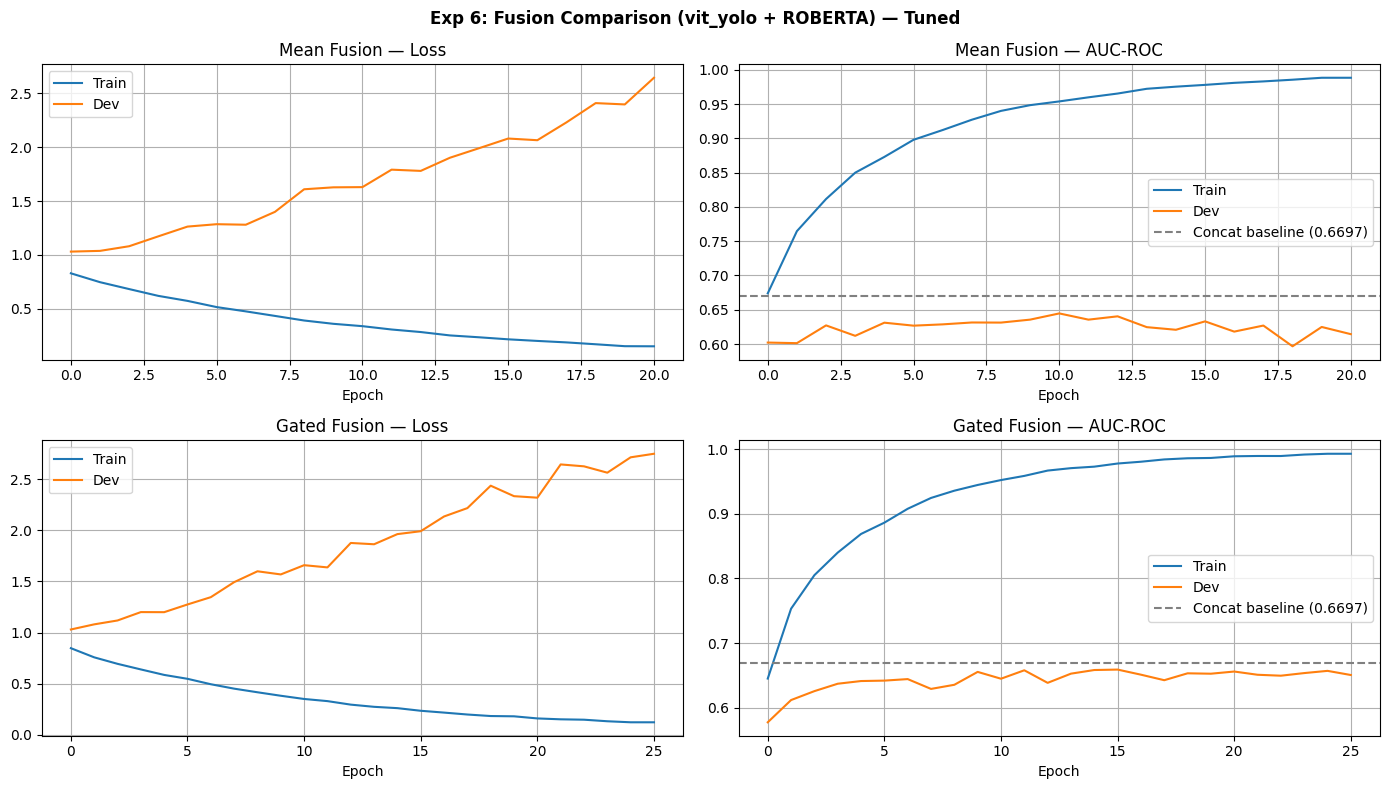

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fusion_labels = {'mean': 'Mean Fusion', 'gated': 'Gated Fusion'}

for row, fusion in enumerate(['mean', 'gated']):
    h = histories[fusion]
    axes[row,0].plot(h['train_loss'], label='Train')
    axes[row,0].plot(h['dev_loss'],   label='Dev')
    axes[row,0].set_title(f'{fusion_labels[fusion]} — Loss')
    axes[row,0].set_xlabel('Epoch'); axes[row,0].legend(); axes[row,0].grid(True)

    axes[row,1].plot(h['train_auc'], label='Train')
    axes[row,1].plot(h['dev_auc'],   label='Dev')
    axes[row,1].axhline(CONCAT_AUC, color='gray', linestyle='--',
                        label=f'Concat baseline ({CONCAT_AUC:.4f})')
    axes[row,1].set_title(f'{fusion_labels[fusion]} — AUC-ROC')
    axes[row,1].set_xlabel('Epoch'); axes[row,1].legend(); axes[row,1].grid(True)

plt.suptitle(f'Exp 6: Fusion Comparison ({BEST_IMG_KEY} + {BEST_TEXT.upper()}) — Tuned',
             fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT / 'outputs/06_training_curves.png', dpi=150)
plt.show()

## 11. Results Summary & Fusion Selection

In [13]:
print('=' * 60)
print(f'EXP 6 — Fusion Comparison | {BEST_IMG_KEY} + {BEST_TEXT.upper()} | Dev Set')
print('=' * 60)
for fusion in ['concat', 'mean', 'gated']:
    r    = results[fusion]
    note = '  [reused]' if fusion == 'concat' else ''
    print(f'  {fusion.upper():8s}: AUC = {r["dev_auc_roc"]:.4f}  Acc = {r["dev_accuracy"]:.4f}{note}')

best_fusion = max(results, key=lambda k: results[k]['dev_auc_roc'])
print(f'\n-> Best fusion: {best_fusion.upper()} (AUC = {results[best_fusion]["dev_auc_roc"]:.4f})')
print(f'   Mean  vs Concat : {results["mean"]["dev_auc_roc"]  - CONCAT_AUC:+.4f}')
print(f'   Gated vs Concat : {results["gated"]["dev_auc_roc"] - CONCAT_AUC:+.4f}')

EXP 6 — Fusion Comparison | vit_yolo + ROBERTA | Dev Set
  CONCAT  : AUC = 0.6697  Acc = 0.5940  [reused]
  MEAN    : AUC = 0.6447  Acc = 0.5980
  GATED   : AUC = 0.6589  Acc = 0.5980

-> Best fusion: CONCAT (AUC = 0.6697)
   Mean  vs Concat : -0.0250
   Gated vs Concat : -0.0108


## 12. Classification Report — Best Fusion

In [14]:
if best_fusion != 'concat':
    _, _, _, best_probs, best_true = run_epoch(
        dev_loader, trained_models[best_fusion],
        nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    )
    print(f'Classification Report — {best_fusion.upper()} fusion ({BEST_IMG_KEY} + {BEST_TEXT}):')
    print(classification_report(best_true, (best_probs >= 0.5).astype(int),
                                 target_names=['Not Hateful', 'Hateful']))
else:
    print('Best fusion is Concat — see Exp 5 for classification report.')

Best fusion is Concat — see Exp 5 for classification report.


## 13. Save Models & Results

In [15]:
os.makedirs(ROOT / 'models', exist_ok=True)
os.makedirs(ROOT / 'outputs', exist_ok=True)

for fusion in ['mean', 'gated']:
    torch.save(trained_models[fusion].state_dict(),
               ROOT / f'models/06_{BEST_IMG_KEY}_{BEST_TEXT}_{fusion}_mlp.pt')

exp6_out = {
    'experiment': '06_FusionSelection',
    'image_backbone': BEST_IMG_KEY, 'img_dim': IMG_DIM,
    'text_backbone': BEST_TEXT, 'text_dim': TEXT_DIM,
    'results': results,
    'best_fusion': best_fusion,
    'gated_weights': trained_models['gated'].get_gates()
}

with open(ROOT / 'results/exp6.json', 'w') as f:
    json.dump(exp6_out, f, indent=2)

print('Saved:')
for fusion in ['mean', 'gated']:
    print(f'  models/06_{BEST_IMG_KEY}_{BEST_TEXT}_{fusion}_mlp.pt')
print('  results/exp6.json')
print(json.dumps(exp6_out, indent=2))

Saved:
  models/06_vit_yolo_roberta_mean_mlp.pt
  models/06_vit_yolo_roberta_gated_mlp.pt
  results/exp6.json
{
  "experiment": "06_FusionSelection",
  "image_backbone": "vit_yolo",
  "img_dim": 768,
  "text_backbone": "roberta",
  "text_dim": 768,
  "results": {
    "concat": {
      "dev_auc_roc": 0.6697,
      "dev_accuracy": 0.594,
      "note": "reused from exp5"
    },
    "mean": {
      "dev_auc_roc": 0.6447,
      "dev_accuracy": 0.598
    },
    "gated": {
      "dev_auc_roc": 0.6589,
      "dev_accuracy": 0.598
    }
  },
  "best_fusion": "concat",
  "gated_weights": {
    "alpha_img": 0.5093,
    "alpha_text": 0.4918
  }
}
